In [15]:
import math 
import random
import matplotlib.pyplot as plt

In [16]:
import random
import matplotlib.pyplot as plt
from engine import Value
from nn import MLP

In [17]:
a = Value(0.8)
b = Value(1.5)
c = Value(0.25)

c = a**3
print(c)

e = (c*2).exp()

d1 = (e - 1)/(e + 1)
d1.backward()
print(a.grad)

Value(data=0.5120000000000001)
1.4931567925684945


In [18]:
samples = [
    [2,5,2,-3],
    [7,-6,1,4],
    [-4,3,-9,-1],
    [1,6,-4,-9]
]

goal = [-1, 1, 1, -1]

random.seed(0)
nn = MLP(4,[4,4,1])

losses = [] 

for k in range (1000):
    nn_pred = [ nn(sample) for sample in samples]
    Loss = sum(((goal[i] - nn_pred[i])**2 ) for i in range(len(samples)))
    losses.append(Loss.data)

    for p in nn.parameters():
            p.grad = 0
    Loss.backward()

    for p in nn.parameters():
        p.data += -0.2*p.grad

print(nn_pred, Loss)

[Value(data=-0.9957071318489049), Value(data=0.9974233209409248), Value(data=0.990331778549179), Value(data=-0.9914671610606435)] Value(data=0.00019135183832327804)


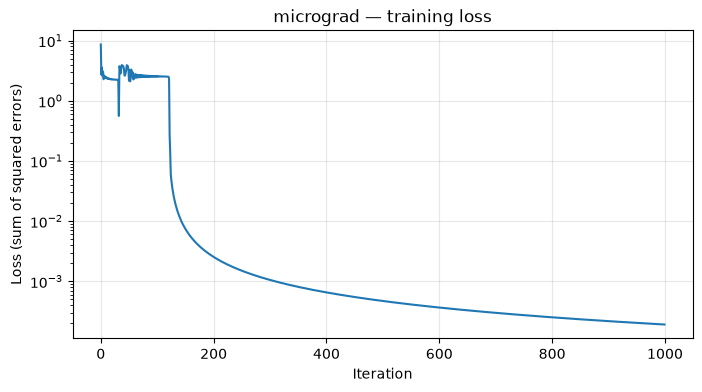

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss (sum of squared errors)")
plt.title("micrograd — training loss")
plt.grid(True, alpha=0.3)
plt.show()